# L19 SQL I

## 1 Databases

**Motivation**

- CSVs work well with relatively small (< 10GB) and unchanged (static) datasets

- However, in practice we often encounter huge and changing constantly data

- Multiple data scientists may need to analysis and make modifications at the same time

<div style="background-color:#3b82f630; padding:12px 16px; border-left:5px solid #3b82f6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Definition:</strong> **Database**

- A **database** is a large, organized collection of data

- Databases are administered by **Database Management Systems (DBMS)**, which are software systems that store, manage, and facilitate access to one or more databases

- Common large-scale DBMS systems used are Google BigQuery, Amazon Redshift, Snowflake, Databricks, Microsoft SQL Server, and more
</div>

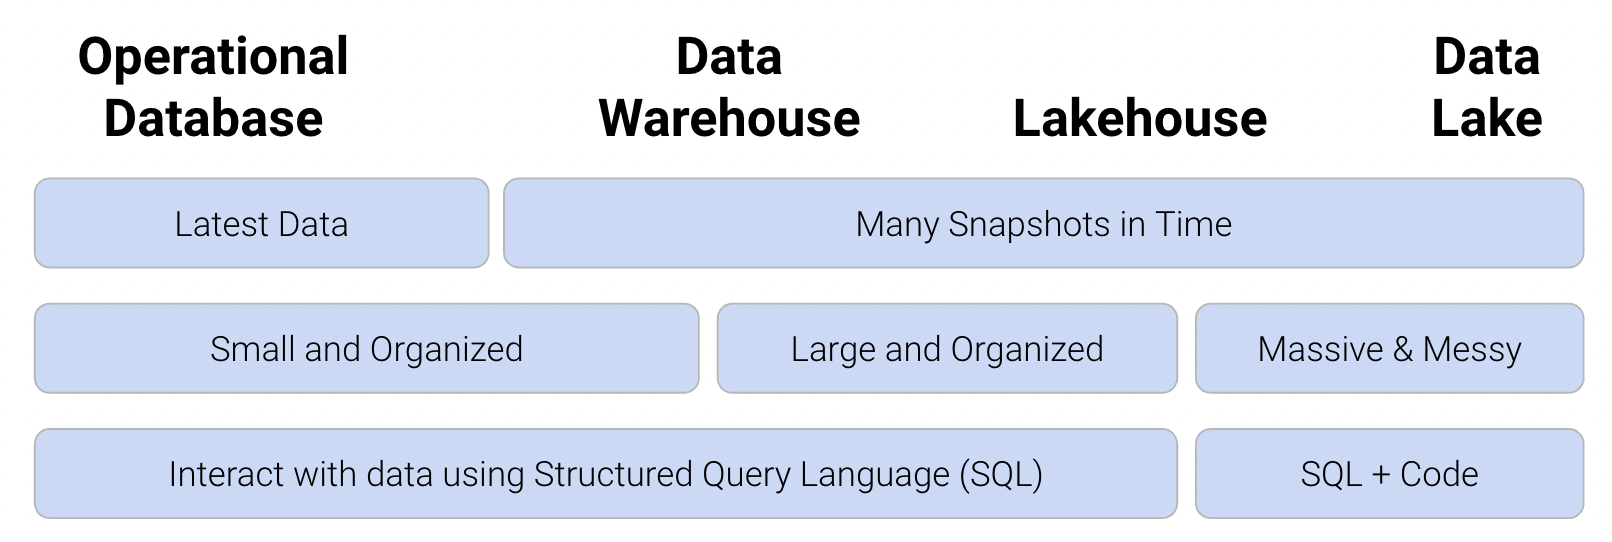

- See more on [Data 101 Data Engineering](https://www.data101.org/sp24/)

- We just cannot use `pandas` methods to work with data in the database, we need SQL

## 2 SQL

- Structured Query Language, or SQL is a special programming language designed to communicate with databases

- It is a language of tables: **all inputs and outputs are tables**

- It is a **declarative programming language**
	
	- Rather than writing the exact logic needed to complete a task, a piece of SQL code **“declares” what the desired final output should be** and leaves the program to determine what logic should be implemented

In [2]:
# Load the SQL Alchemy Python library and DuckDB
import sqlalchemy
import duckdb

- For more setting details, see [Github](https://github.com/DS-100/course-notes/blob/main/requirements.txt)

In [3]:
# Load %%sql cell magic
%load_ext sql

In [4]:
# Connect to the database
%sql duckdb:///example_duck.db --alias duck

Connecting to 'duck'

- Now that we’re connected

- SQL statements are **terminated with semicolons `;`**

  - A SQL query is a SQL statement that returns data

In [6]:
%%sql

SELECT * FROM Dragon; # All entries (rows)

Running query in 'duck'

name,year,cute
hiccup,2010,10
drogon,2011,-100
dragon 2,2019,0
puff,2010,100
smaug,2011,None


## 3 Tables & Schema

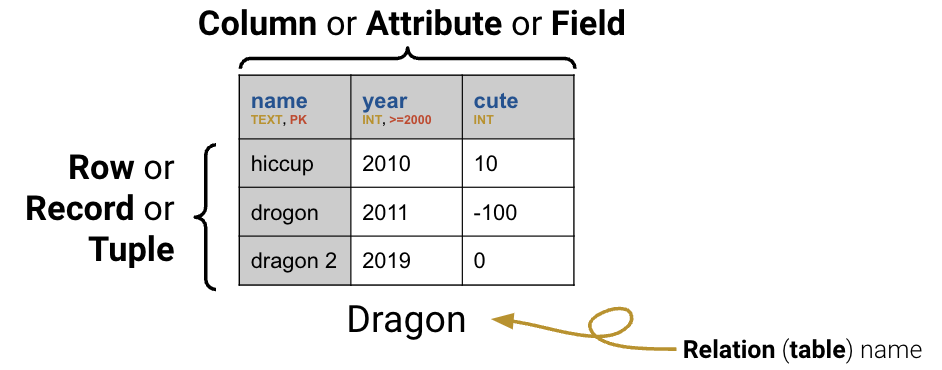

- Let's see the schema of our database

- A **schema** describes the logical structure of a table
  
- **Whenever a new table is created, the creator must declare its schema**

In [7]:
%%sql

SELECT *
FROM sqlite_master
WHERE type='table'

Running query in 'duck'

type,name,tbl_name,rootpage,sql
table,dish,dish,0,"CREATE TABLE dish(""name"" VARCHAR PRIMARY KEY, ""type"" VARCHAR, ""cost"" INTEGER, CHECK((""cost"" >= 0)));"
table,dragon,dragon,0,"CREATE TABLE dragon(""name"" VARCHAR PRIMARY KEY, ""year"" INTEGER, cute INTEGER, CHECK((""year"" >= 2000)));"
table,scene,scene,0,"CREATE TABLE scene(id INTEGER PRIMARY KEY, biome VARCHAR NOT NULL, city VARCHAR NOT NULL, visitors INTEGER, created_at TIMESTAMP DEFAULT(current_date()), CHECK((visitors >= 0)));"


- The summary displays info about the database

	- It contains three tables named `Dragon`, `Dish`, and `Scene`
	
	- The **rightmost column** above lists the **command that was used to construct each table**

- Let's see one of those

In [ ]:
CREATE TABLE Dragon (name TEXT PRIMARY KEY,
                     year INTEGER CHECK (year >= 2000),
                     cute INTEGER)

- `CREATE TABLE` is used to specify the schema of the table (a description of what logic is used to organize the table)

- Schema follows a set format:
  
  - `ColName`: the name of a column
  
  - `DataType`: the type of data to be stored in a column
  
    - `INT`, `FLOAT`, `VARCHAR` (`TEXT`), `BLOB` (arbitrary data, such as audio/video files), `DATATIME`
  
  - `Constraint`: some restriction on the data to be stored in the column
  
    - `CHECK` (data must obey a certain condition)
    
	- `PRIMARY KEY` (designate a column as the table’s primary key)
	
	- `NOT NULL` (data cannot be null)
	
	- `DEFAULT` (a default fill value if no specific entry is given)

### Primary Keys

- The primary key is a set of column(s) that **uniquely identify each record** in the table

- Used to **ensure data integrity** and to **optimize data access**

### Foreign Keys

- A foreign key is a column or set of columns that **references a primary key in another table**

**e.g.**

In [ ]:
CREATE TABLE student (
    student_id INTEGER PRIMARY KEY,
    name VARCHAR,
    email VARCHAR
);

CREATE TABLE assignment (
    assignment_id INTEGER PRIMARY KEY,
    description VARCHAR
);

In [ ]:
CREATE TABLE grade (
    student_id INTEGER,
    assignment_id INTEGER,
    score REAL,
    FOREIGN KEY (student_id) REFERENCES student(student_id),
    FOREIGN KEY (assignment_id) REFERENCES assignment(assignment_id)
);

- Table `grade` has 2 foreign keys `student_id` & `assignment_id` which refers to the primary keys to another 2 tables

## 4 Basic Queries

### `SELECT` ... `FROM` ...

In [ ]:
%%sql

SELECT * 
# * means "everything", it grabs all cols
FROM Dragon;

Running query in 'duck'

name,year,cute
hiccup,2010,10
drogon,2011,-100
dragon 2,2019,0
puff,2010,100
smaug,2011,None


- We can also specify which cols we want to select

- Output order is the same as the order in which we select

In [9]:
%%sql

SELECT cute, year
FROM Dragon;

Running query in 'duck'

cute,year
10,2010
-100,2011
0,2019
100,2010
None,2011


- SQL enforces a strict “order of operations” — **SQL clauses must always follow the same sequence**
  
  - e.g. the `SELECT` statement must always precede `FROM`. This means that any SQL query will follow the same structure

In [ ]:
SELECT <column list>
FROM <table>
[additional clauses]

**SQL Style Conventions**

- Every **“verb” uppercase**

- Separates **each statement with a new line**

- The semicolon `;` indicates the **end of a query**

**Aliasing `AS`**

- `AS` can give a col a new name (alias) after selected

In [ ]:
SELECT column_in_input_table AS new_name_in_output_table

In [10]:
%%sql
SELECT cute AS cuteness, year AS birth
FROM Dragon;

Running query in 'duck'

cuteness,birth
10,2010
-100,2011
0,2019
100,2010
None,2011


**Uniqueness `DISTINCT`**

- To select only the unique value in a col

- Any duplicates in a col will be removed

In [11]:
%%sql

SELECT DISTINCT year
FROM Dragon;

Running query in 'duck'

year
2010
2019
2011


### `WHERE` & `IN` Conditions

- `WHERE` can filter rows with a given Boolean conditions (`AND`, `OR`, `NOT`)

In [14]:
%%sql

SELECT name, year
FROM Dragon
WHERE cute > 0 OR year > 2013;

Running query in 'duck'

name,year
hiccup,2010
dragon 2,2019
puff,2010


- To spare from using complicated logical expressions, we can also use `IN` for a set of specific options using `('str_1', ..., 'str_n')`

In [15]:
%%sql

SELECT name, year
FROM Dragon
WHERE name IN ('hiccup', 'puff');

Running query in 'duck'

name,year
hiccup,2010
puff,2010


- Notice we use `str` in the tuple

**Strings in SQL**

- `""`: col names

- `''`: strings

In [ ]:
SELECT "birth weight"
FROM patient
WHERE "first name" = 'Joey';

- column `"first name"` is equal to string `'Joey'`

- Cannot write `"Joey"`, which will run error

**`NULL`** & `IS` & `IS NOT`

- In SQL, missing data is given the special value `NULL`

- `NULL` behaves in a **fundamentally different** way to other data types

	- Cannot use operators (`=`, `>`, and `<`) on `NULL` (in fact, `NULL == NULL` returns `False`!)
	
	- We need to use `IS` or `IS NOT NULL`

In [17]:
%%sql

SELECT name, cute
FROM Dragon
WHERE cute IS NOT NULL;

Running query in 'duck'

name,cute
hiccup,10
drogon,-100
dragon 2,0
puff,100


### `ORDER BY` Sorting

- You want the output to appear in a certain order

- Like `.sort_values()`

In [18]:
%%sql

SELECT *
FROM Dragon
ORDER BY cute;

Running query in 'duck'

name,year,cute
drogon,2011,-100
dragon 2,2019,0
hiccup,2010,10
puff,2010,100
smaug,2011,None


- By default, it starts at smaller number and increases (just like counting from 1)

	- `ASC`: ascending order
  
- For deceasing order, use `DESC`: descending order

In [19]:
%%sql

SELECT *
FROM Dragon
ORDER BY cute DESC;

Running query in 'duck'

name,year,cute
puff,2010,100
hiccup,2010,10
dragon 2,2019,0
drogon,2011,-100
smaug,2011,None


- We can also `ORDER BY` multiple cols, SQL will **sort for the first, then within each subgroup it will sort for the last**

In [20]:
%%sql

SELECT *
FROM Dragon
ORDER BY year, cute DESC;

Running query in 'duck'

name,year,cute
puff,2010,100
hiccup,2010,10
drogon,2011,-100
smaug,2011,None
dragon 2,2019,0


- `year` is in ascending order, `cute` is in descending order

	- 先对第一列sorting，这里是`year`升序；然后会对每个年份内部进行第二列的sorting，每个年份组里面`cute`降序

- To make `year` in desending order too, you need to:

In [21]:
%%sql

SELECT *
FROM Dragon
ORDER BY year DESC, cute DESC;

Running query in 'duck'

name,year,cute
dragon 2,2019,0
drogon,2011,-100
smaug,2011,None
puff,2010,100
hiccup,2010,10


<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- `DESC` is col-based, you need to specify for each col

</div>

### `LIMIT` & `OFFSET` Restricting Output

- We may only concern certain number of rows in the output table like the first $n$ rows or the last $m$ rows

- Like `.head()`

In [22]:
%%sql

SELECT *
FROM Dragon
LIMIT 2;

Running query in 'duck'

name,year,cute
hiccup,2010,10
drogon,2011,-100


- `OFFSET` indicates the index at which `LIMIT` should start

**e.g.**

- We might want to check position 2 & 3 in the table

	- `LIMIT` $(3-2)+1=2$ rows In total
	
	- `OFFSET` / Shifting $2-1=1$ row(s)

In [23]:
%%sql

SELECT *
FROM Dragon
LIMIT 2
OFFSET 1;

Running query in 'duck'

name,year,cute
drogon,2011,-100
dragon 2,2019,0


In [ ]:
--- Summary ---

SELECT <column expression list>
FROM <table>
[WHERE <predicate>]
[ORDER BY <column list>]
[LIMIT <number of rows>]
[OFFSET <number of rows>];

### `RANDOM` & `SAMPLE` Sampling the Dataset

- We can use `RANDOM` & `SAMPLE` to get a sample of the dataset

- `RANDOM` will randomize the entire table

In [53]:
%%sql

SELECT *
FROM Dragon
ORDER BY RANDOM() # We randomize the whole table first
LIMIT 2; # Then we pick the first 2 rows of the randomized table

# You can run it multiple times
# Each time it will rerandomize and yield a new table

Running query in 'duck'

name,year,cute
drogon,2011,-100
hiccup,2010,10


- What if you don't want to get a whole new table each time you run?

  - Like you want the result to be reproducible

- `SAMPLE` uses a seed to randomly draw samples from the table

- `REPEATABLE` keyword is used here as a seed so that the same rows are drawn each time we run this

	- More efficient

In [61]:
%%sql

SELECT *
FROM Dragon
USING SAMPLE reservoir(2 ROWS) REPEATABLE (233);

Running query in 'duck'

name,year,cute
drogon,2011,-100
dragon 2,2019,0


- `reservoir(2 ROWS)`: using reservoir sample method to take 2 rows out

- `REPEATABLE (233)`: 233 is just a seed number, it doesn't have any meanings

<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **Why it is more efficient?**

`RANDOM`

- It first generates a random number for every row

- Then it sorts the random numbers

- Then it takes $n$ rows out

`SAMPLE`

- For the first $n$ rows, it just puts them into sample first

- For later rows, it uses some prob. to decide whether to replace one row in the sample

**`SAMPLE` doesn't need to sort, so it is faster**

</div>

In [ ]:
--- Summary ---

SELECT <column list>
FROM <table>
[WHERE <predicate>]
[ORDER BY <column list>]
[LIMIT <number of rows>]
[OFFSET <number of rows>]

---
[Reference](https://ds100.org/course-notes/sql-i/)